<a href="https://colab.research.google.com/github/cp-16-bio/Breast-Cancer-Detection-Model/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Description:** This program serves to detect breast cancer based off of real-world data.

# Part 1: Exploring, Manipulating, and Cleaning the Data

In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the data (on Google website --> have to use Google library to load data from your computer)
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('data.csv')
df.head(7) # Print the first 7 rows of data

##NOTES FOR THE DATASET
#M = (M)alignant --> cancerous
#B = (B)enign --> non-cancerous

Saving data.csv to data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN


In [ ]:
##Count the number of rows and columns in the data set
#Each row represents a patient and columns represent features/data-points
df.shape

(569, 33)

In [ ]:
#Count the number of empty values in each column (i.e. NaN, NAN, na)
df.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
#Drop the column(s) with empty values
df = df.dropna(axis=1) #Gives a new dataset without the empty column (axis=1)
                       #and stores back into the original dataframe

In [ ]:
#Recieve the new count of the number of rows and columns
df.shape

(569, 32)

In [ ]:
#Get a count of the number of (M)alignant or (B)enign cells
df['diagnosis'].value_counts() #Access the 'diagnosis' column to get the values

,count
diagnosis,
B,357
M,212


<Axes: xlabel='count', ylabel='diagnosis'>

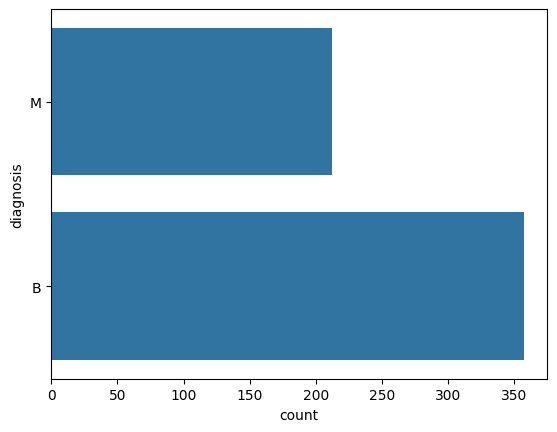

In [ ]:
#Visualize the (M)alignant and (B)enign cell count
sns.countplot(df['diagnosis'],label='Count')

In [ ]:
#Look at the data types to understand which columns need to be encoded
#(i.e, transform into a number value)
df.dtypes

#Determine which information is important and not (e.g. patient 'id'
#isn't necessary for detection purposes)

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [ ]:
#Encode the categorical data values
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
df.iloc[:,1] = labelencoder_Y.fit_transform(df.iloc[:,1].values) #All rows for diagnosis (index 1)
#Inputting an array into this function --> 'M' is 1 and 'B' is 0

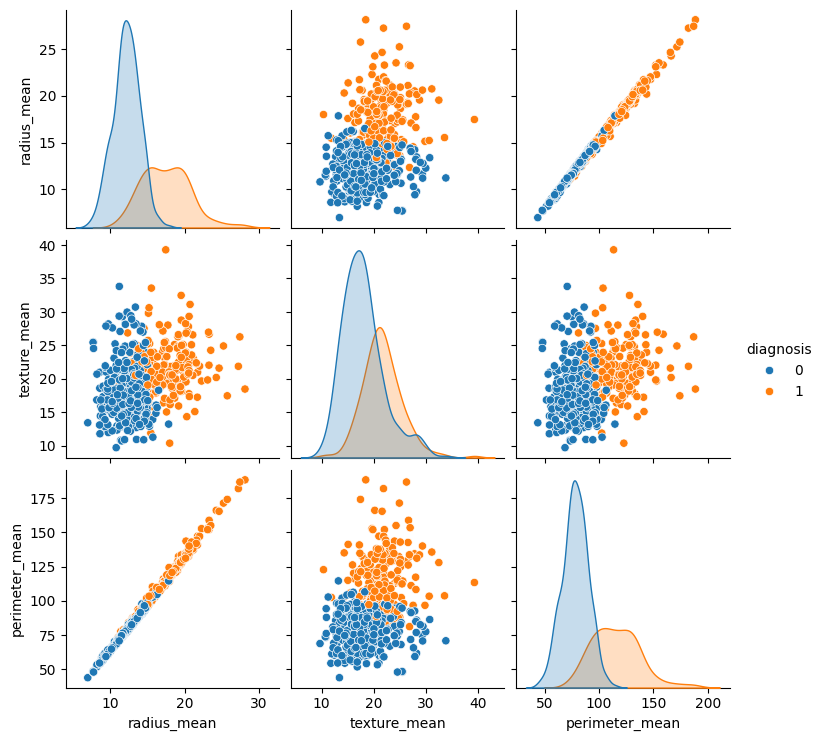

In [ ]:
#Create a pair plot
sns.pairplot(df.iloc[:,1:5], hue='diagnosis') #Get all the rows up to but not including index 5
                                              #and visualize diagnosis points (M vs B) on the
                                              #graphs in different colors

In [ ]:
#Print the first 5 rows of the new dataset
df.head(5) #Should see 1s and 0s in 'diagnosis' column and no Nan values

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#Obtain the correlation of the columns
df.iloc[:,1:12].corr() #Gets how one column influences the other

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,-0.012838
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921


<Axes: >

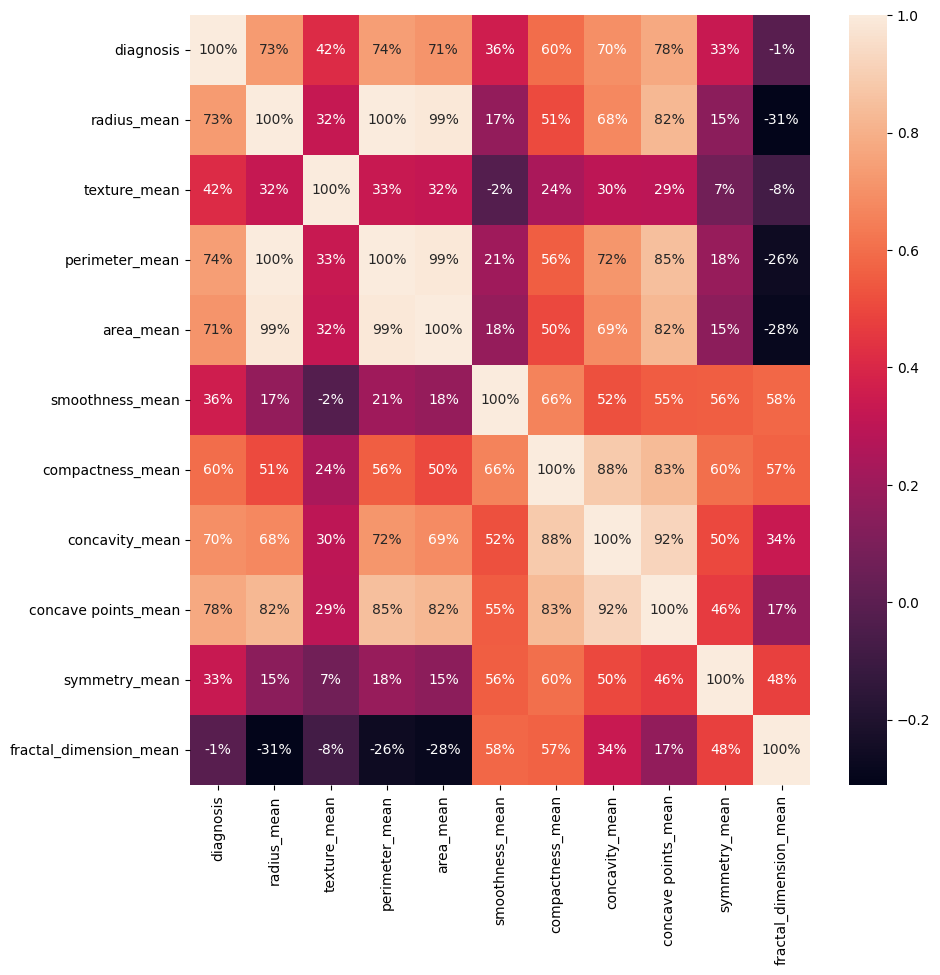

In [ ]:
#Visualize the correlation
plt.figure(figsize=(10,10)) #Change figure size for clearer visualization
sns.heatmap(df.iloc[:,1:12].corr(), annot=True, fmt='.0%') #Add percentage values inside of the cells

# Part 2: Creating the Model to Detect Cancerous Cells

In [ ]:
#Split the dataset into independent (X) and dependent (Y) datasets
X = df.iloc[:,2:31].values #Contains all of the rows of data from the column
                           #after 'diagnosis' to the last column in an array
                           #(i.e. tells us the features that can detect if the
                           #patient has cancer or not)

Y = df.iloc[:,1].values #Contains all of the rows of data from the 'diagnosis' column
                        #in an array (i.e. tells us if the patient has cancer or not)

In [ ]:
#Split the dataset into 75% training and 25% testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [ ]:
#Scale the data to bring all the features to the same order of magnitude (Feature Scaling)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [ ]:
#Create a function for the cancer-detecting models
def models(X_train, Y_train):

  #Logistic Regression model
  from sklearn.linear_model import LogisticRegression
  log = LogisticRegression(random_state = 0)
  log.fit(X_train, Y_train)

  #Decision Tree model
  from sklearn.tree import DecisionTreeClassifier
  tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
  tree.fit(X_train, Y_train)

  #Random Forest Classifier model
  from sklearn.ensemble import RandomForestClassifier
  forest = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
  forest.fit(X_train, Y_train)

  #Print the models' accuracy on the training data
  print('[0]Logistic Regression Training Accuracy:', log.score(X_train, Y_train))
  print('[1]Decision Tree Classifier Training Accuracy:', tree.score(X_train, Y_train))
  print('[2]Random Forest Classifier Training Accuracy:', forest.score(X_train, Y_train))

  return log, tree, forest

In [ ]:
#Recieve all of the models
model = models(X_train, Y_train.astype(int)) #See accuracy of each training model

[0]Logistic Regression Training Accuracy: 0.9906103286384976
[1]Decision Tree Classifier Training Accuracy: 1.0
[2]Random Forest Classifier Training Accuracy: 0.9953051643192489


In [ ]:
#Test each models' accuracy on the test data using a Confusion Matrix
from sklearn.metrics import confusion_matrix

for i in range(len(model)):
  print('Model' , i)
  cm = confusion_matrix(Y_test.astype(int), model[i].predict(X_test)) #Input models' predictions for testing data
  print(cm)                                                           #to give us what it thinks the actual values for the features
                                                                      #are in the testing data

  #Get the accuracy of the model on the testing data using the values from the cm
  TP = cm[1][1]   #(T)rue (P)ositive
  TN = cm[0][0]   #(T)rue (N)egative
  FN = cm[1][0]   #(F)alse (N)egative
  FP = cm[0][1]   #(F)alse (P)ositive
  print('Model Tesing Accuracy = ' , (TP + TN) / (TP + TN + FN + FP))
  print()

Model 0
[[86  4]
 [ 3 50]]
Model Tesing Accuracy =  0.951048951048951

Model 1
[[83  7]
 [ 2 51]]
Model Tesing Accuracy =  0.9370629370629371

Model 2
[[87  3]
 [ 2 51]]
Model Tesing Accuracy =  0.965034965034965



In [ ]:
#Provide another way to get metrics of the models
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

for i in range(len(model)):
  print('Model' , i)
  print(classification_report(Y_test.astype(int), model[i].predict(X_test)))
  print(accuracy_score(Y_test.astype(int), model[i].predict(X_test)))
  print()

Model 0
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        90
           1       0.93      0.94      0.93        53

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

0.951048951048951

Model 1
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        90
           1       0.88      0.96      0.92        53

    accuracy                           0.94       143
   macro avg       0.93      0.94      0.93       143
weighted avg       0.94      0.94      0.94       143

0.9370629370629371

Model 2
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        90
           1       0.94      0.96      0.95        53

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted av

In [ ]:
##Determine which model did the best generalizing the test data
#In this case: Random Forest Classifier model

#Print the prediction of the Random Forest Classifier model
pred = model[2].predict(X_test) #Predict (i.e. decide whether or not the patient has cancer)
                                #the values on the features of the testing data
print(pred)
print()
print(Y_test) #Print the actual values

##NOTES FOR THE DATA
#First array is what the model predicts
#Second array is the actual values of the patients

[1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0
 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1]

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 1
 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0
 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1]
